<a href="https://colab.research.google.com/github/AmaadZiaGit/Machine-Learning-/blob/main/Phishing_data_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loaded: 48 features identified.
Linear Regression MSE: 0.0768
Logistic Regression Accuracy: 0.9390
Decision Tree Accuracy: 0.9705
Random Forest Accuracy: 0.9820
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MLP Accuracy: 0.9675
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1D-CNN Accuracy: 0.9725


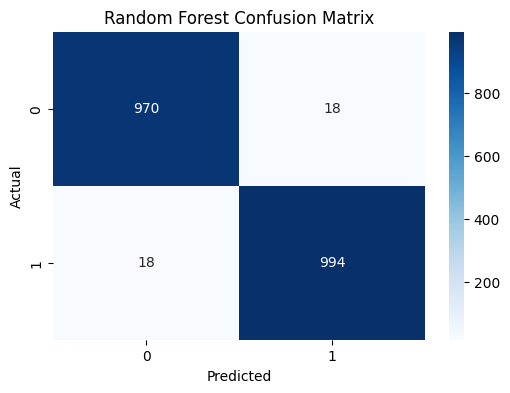


--- Final Report Metrics ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       988
           1       0.98      0.98      0.98      1012

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [17]:

# Download neccessary data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # This is used for interactive visualizations
import seaborn as sns # This is used to mkae sure the charts look better
from sklearn.model_selection import train_test_split # This splits the data
from sklearn.preprocessing import StandardScaler # Normalizes data for Deep Learning
from sklearn.tree import DecisionTreeClassifier # This model used for Phishing classification
from sklearn.linear_model import LinearRegression # The model used to predict a continuous value
from sklearn.linear_model import LogisticRegression # Baseline classifier for binary Phishing detection
from sklearn.ensemble import RandomForestClassifier # Ensemble model to prevent overfitting
from sklearn.metrics import accuracy_score # This predictions the classifier got right
from sklearn.metrics import classification_report # This shows precision, recall, and f1-score
from sklearn.metrics import confusion_matrix # A table showing exactly where errors happened
from sklearn.metrics import mean_squared_error # Measures error distance for regression
from sklearn.metrics import r2_score # Measures how well the regression line fits

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, MaxPooling1D

# 1. Load Dataset
# Ensure the file 'Phishing_Legitimate_full.csv' is in the same folder
df = pd.read_csv('Phishing_Legitimate_full.csv')

# Drop ID and separate Target (CLASS_LABEL)
X = df.drop(['id', 'CLASS_LABEL'], axis=1)
y = df['CLASS_LABEL']
num_features = X.shape[1]

# 2. Preprocessing
# Split 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# StandardScaler (Critical for MLP/CNN convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Loaded: {num_features} features identified.")

# ML 1: Linear Regression - Used for Risk Scoring
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_pred = lin_reg.predict(X_test_scaled)
print(f"Linear Regression MSE: {mean_squared_error(y_test, lin_pred):.4f}")

# ML 2: Logistic Regression - Baseline Classifier
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_pred):.4f}")

# ML 3: Decision Tree - Interpretability
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
dt_pred = dtree.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.4f}")

# ML 4: Random Forest (Core) - Robust Ensemble
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

# DL 1: MLP (Multi-Layer Perceptron)
mlp = Sequential([
    Input(shape=(num_features,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=0)
mlp_pred = (mlp.predict(X_test_scaled) > 0.5).astype("int32")
print(f"MLP Accuracy: {accuracy_score(y_test, mlp_pred):.4f}")

# DL 2: 1D-CNN
# Reshape for CNN: (Samples, Features, 1)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], num_features, 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], num_features, 1)

cnn = Sequential([
    Input(shape=(num_features, 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_cnn, y_train, epochs=10, batch_size=32, verbose=0)
cnn_pred = (cnn.predict(X_test_cnn) > 0.5).astype("int32")
print(f"1D-CNN Accuracy: {accuracy_score(y_test, cnn_pred):.4f}")

# Confusion Matrix

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n--- Final Report Metrics ---")
print(classification_report(y_test, rf_pred))